# Добавление нового аттрибута

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("penguins_size.csv")

Добавим аналог ИМТ

In [2]:
df["body_condition_index"] = df["body_mass_g"] / (df["flipper_length_mm"] ** 2)

numeric_cols = df.select_dtypes("number").columns

# Причесывание датасета

## Удаление выбросов и дублей

In [3]:
def find_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series[(series < lower) | (series > upper)]

for col in numeric_cols:
    for sp, group in df.groupby("species"):
        outliers_idx = find_outliers_iqr(group[col]).index
        df = df.drop(outliers_idx)
        

In [4]:
print(df.duplicated().sum())

0


Дублей нет

## Обработка пропущенных значений

In [5]:
df = df.dropna(subset=["sex"])

df.isnull().sum()

species                 0
island                  0
culmen_length_mm        0
culmen_depth_mm         0
flipper_length_mm       0
body_mass_g             0
sex                     0
body_condition_index    0
dtype: int64

## Поиск кривых данных

In [6]:
print(df["species"].unique())
print(df["island"].unique())
print(df["sex"].unique())

<StringArray>
['Adelie', 'Chinstrap', 'Gentoo']
Length: 3, dtype: str
<StringArray>
['Torgersen', 'Biscoe', 'Dream']
Length: 3, dtype: str
<StringArray>
['MALE', 'FEMALE', '.']
Length: 3, dtype: str


In [7]:
df = df[df["sex"] != "."]

In [8]:
df = df.reset_index(drop=True)

# Графики зависимости

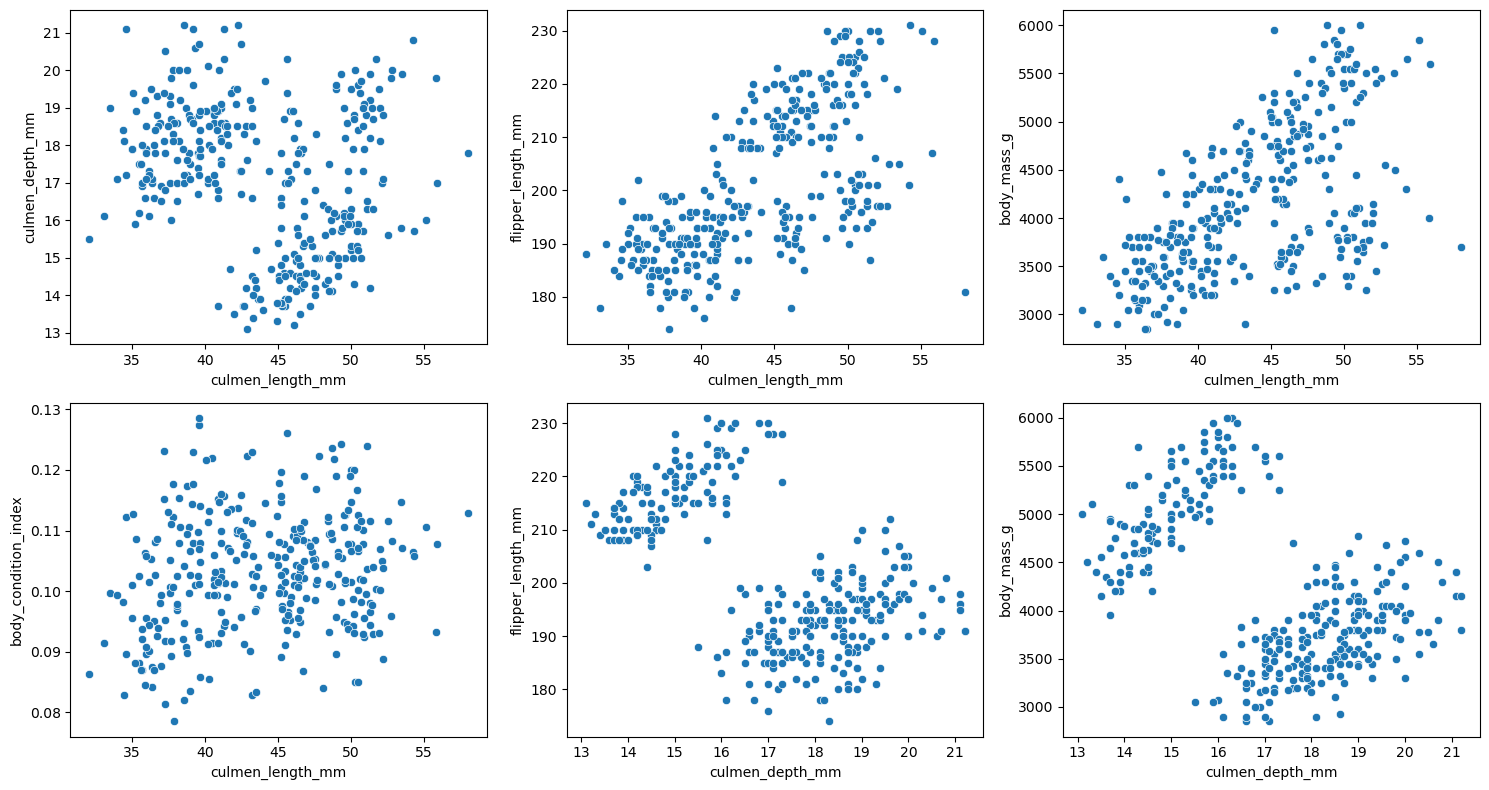

In [ ]:
from itertools import combinations

pairs = list(combinations(numeric_cols, 2))

n = len(pairs)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (x, y) in zip(axes.flatten(), pairs):
    sns.scatterplot(data=df, x=x, y=y, ax=ax)

plt.tight_layout()
plt.show()

## Анализ диаграмм рассеивания

На большинстве пар признаков точки образуют не единое облако, а два визуально различимых кластера.

**culmen_length_mm vs culmen_depth_mm** — два облака, разделённых по глубине клюва. По длине клюва чёткой границы между облаками нет, они частично перекрываются.

**culmen_length_mm vs flipper_length_mm** — два кластера, разделённых по длине ласт.

**culmen_length_mm vs body_mass_g** — два кластера, разделённых по массе тела.

**culmen_depth_mm vs flipper_length_mm** — самое чёткое разделение среди всех графиков: два почти не пересекающихся облака, граница между ними резкая, почти без промежуточных точек.

**culmen_depth_mm vs body_mass_g** — также хорошо разделены на две группы: с более глубоким клювом и меньшей массой, и с менее глубоким клювом и большей массой.

**flipper_length_mm vs body_mass_g** — кластеры выражены слабее: облако скорее одно, вытянутое по диагонали (выраженный линейный тренд), с уплотнением в противоположных углах, но без резкого разрыва между группами.

**Вывод.** Признак culmen_depth_mm формирует наиболее чёткое разделение данных на две группы во всех парах, где он участвует. Пара flipper_length_mm–body_mass_g демонстрирует скорее непрерывный тренд, чем изолированные кластеры.

# KMeans

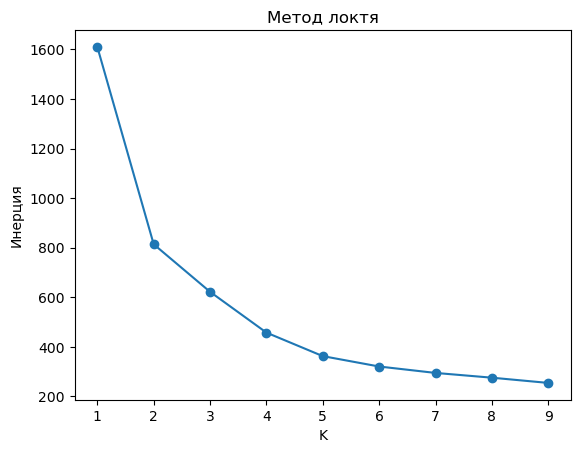

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(df[numeric_cols])

inertia = []
K_range = range(1, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.xlabel("K")
plt.ylabel("Инерция")
plt.title("Метод локтя")
plt.show()

Выберем число кластеров 3


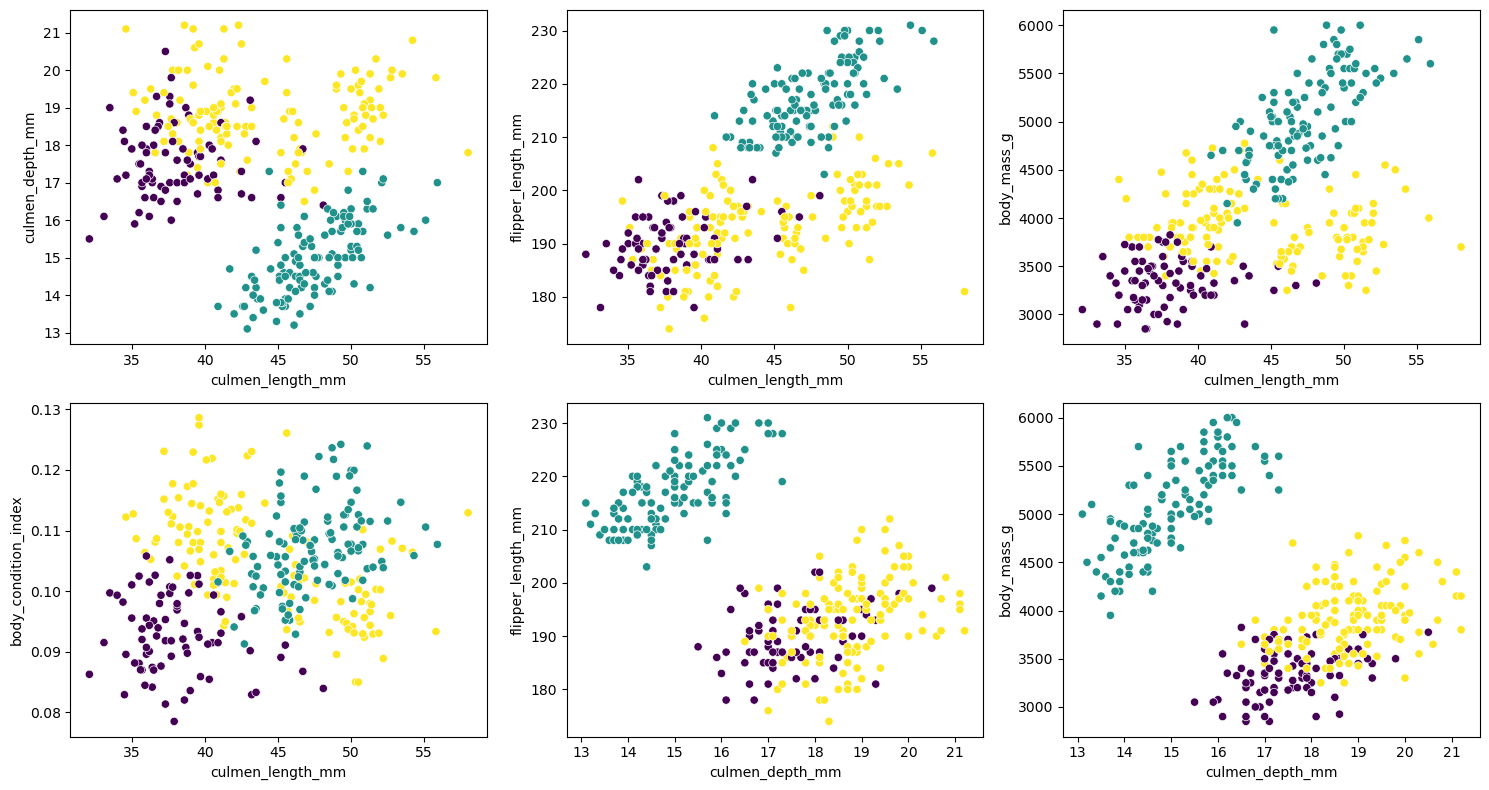

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (x, y) in zip(axes.flatten(), pairs):
    sns.scatterplot(data=df, x=x, y=y, hue="cluster", palette="viridis", ax=ax, legend=False)

plt.tight_layout()
plt.show()

## Метрики оценки качества классификации

**Accuracy** -- доля правильно классифицированных объектов от общего числа объектов в тестовой выборке. 

**Precision (точность)** -- доля объектов, действительно принадлежащих классу, среди всех объектов, отнесённых моделью к этому классу. Отражает, насколько модель избегает ложных срабатываний.

**Recall (полнота)** -- доля объектов класса, которые модель правильно нашла, среди всех объектов, реально принадлежащих этому классу. Отражает, насколько модель не пропускает представителей класса.

**F-measure (F1-score)** -- гармоническое среднее Precision и Recall. Объединяет обе метрики в одно значение и особенно полезен, когда важен баланс между ними, а не только одна из сторон.

**ROC-кривая** -- график зависимости доли истинноположительных срабатываний (TPR) от доли ложноположительных срабатываний (FPR) при варьировании порога классификации. Показывает способность модели разделять классы по предсказанным вероятностям, а не только по итоговому решению.

**AUC (площадь под ROC-кривой)** -- числовая мера качества классификатора, принимающая значения от 0 до 1. Значение, близкое к 1, означает высокую способность модели разделять классы; значение 0.5 соответствует случайному угадыванию.

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# каждому кластеру сопоставляем вид, который в нём преобладает
cluster_to_species = pd.crosstab(df["species"], df["cluster"]).idxmax(axis=0)
y_true = df["species"]
kmeans_pred = df["cluster"].map(cluster_to_species)

results = pd.DataFrame({
    "Model": ["KMeans"],
    "Accuracy": [accuracy_score(y_true, kmeans_pred)],
    "Precision": [precision_score(y_true, kmeans_pred, average="macro", zero_division=0)],
    "Recall": [recall_score(y_true, kmeans_pred, average="macro", zero_division=0)],
    "F-measure": [f1_score(y_true, kmeans_pred, average="macro", zero_division=0)]
})

results

,Model,Accuracy,Precision,Recall,F-measure
0,KMeans,0.798137,0.561997,0.666667,0.604585


Построим тоже самое но покраской по видам

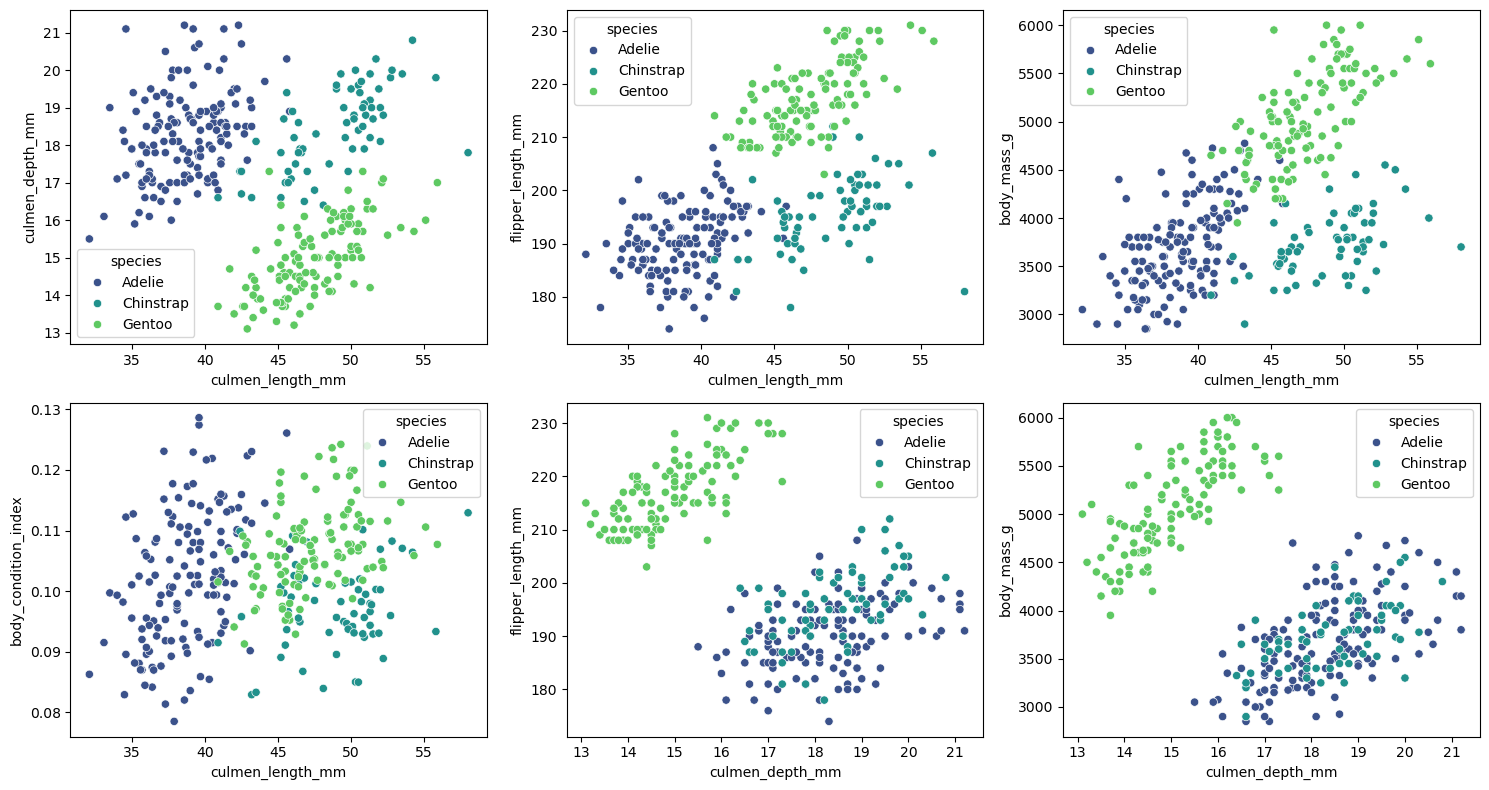

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (x, y) in zip(axes.flatten(), pairs):
    sns.scatterplot(data=df, x=x, y=y, hue="species", palette="viridis", ax=ax)

plt.tight_layout()
plt.show()

## Выводы по KMeans (K=3)

Сравнение кластеризации KMeans с фактическим распределением по видам показывает высокое сходство: три кластера, найденные алгоритмом без учителя, почти полностью совпадают с реальными видами пингвинов.

Kmeans с K=3, выбранным по методу локтя, самостоятельно нашёл структуру данных, которая практически совпадает с биологическим делением на виды — это подтверждает, что выбранные числовые признаки (особенно culmen_depth_mm и flipper_length_mm) действительно информативны и хорошо разделяют группы, даже без использования метки species при обучении.